<div align="left">
    <img src="../assets/logo_evaliax.png" width="450"
         alt="EVALIAX logo"/>
</div>

#  EVALIAX Tutorial: Interpretable AI for Causal Forest

Traditional Causal Forest models are highly flexible and powerful for estimating heterogeneous treatment effects (HTEs). However, this flexibility often comes at the cost of interpretability. Although ensemble-based causal machine learning methods can uncover complex nonlinear relationships, their internal decision-making process may be difficult to understand for policymakers and practitioners.

In public policy evaluation, this limitation is particularly relevant because policy recommendations should not only be accurate, but also transparent, explainable, and interpretable. Recent literature on Explainable AI (XAI) and Interpretable AI (IAI) has emphasized the importance of developing methods that make machine learning models more understandable and auditable, especially in high-stakes domains such as healthcare, finance, and public policy \citep{LundbergLee2017,Semenova2022,RehillBiddle2024}.

This notebook extends the previous Causal Forest example by incorporating interpretable AI techniques that help translate complex heterogeneous treatment effect estimations into more transparent policy insights.

In particular, we introduce:

- **Rashomon Curve**: a framework for analyzing the trade-off between predictive performance and interpretability by comparing simpler and more complex representations of the causal model \citep{Semenova2022}.

- **Best Linear Projection (BLP)**: an interpretable approximation of heterogeneous treatment effects that summarizes the main drivers of treatment heterogeneity using a linear representation.

- **Interpretability vs Precision Trade-off**: the idea that highly flexible models may achieve greater predictive accuracy, while simpler models may offer better transparency and usability for policymakers.

These tools aim to move from black-box causal estimation toward more transparent and interpretable policy evaluation frameworks.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from econml.dml import CausalForestDML


In [2]:

# Load dataset

df = pd.read_csv(
    "../output/simulated_subsidy_dataset_with_causal_forest_results.csv"
)

print(df.head())
print(df.shape)


   firm_id  size  age sector_code             sector_description  \
0        1    30   40           C                  Manufacturing   
1        2    18    1           J  Information and communication   
2        3    34    4           C                  Manufacturing   
3        4    68   30           J  Information and communication   
4        5    17   12           H     Transportation and storage   

   productivity  debt_ratio  profitability     region  aid_received  \
0     67.838397    0.357878       0.150633     Murcia             1   
1     60.008677    0.160489       0.068931    Galicia             0   
2     49.576732    0.054043       0.023460   Valencia             1   
3     70.464894    0.053263       0.105453  Andalusia             1   
4     59.938041    0.206822       0.060447     Madrid             1   

   p_treatment  grant_amount  log_grant_amount  true_effect  \
0     0.535370   5138.028620          8.544619     2.300506   
1     0.565620      0.000000          


# 1. Rashomon Curve

The Rashomon Curve illustrates the trade-off between:

- interpretability
- and causal accuracy.

This idea is closely related to the Rashomon Effect and the notion of the [Semenova, Rudin, and Parr (2022)](https://doi.org/10.1093/ectj/utaa027)


In [12]:

# Prepare variables

Y = df["value_added_growth"]
T = df["aid_received"]

X = df[
    [
        "size",
        "age",
        "sector_code",
        "productivity",
        "debt_ratio",
        "profitability",
        "region"
    ]
]

true_effect = df["true_effect"]

X_encoded = pd.get_dummies(
    X,
    columns=["sector_code", "region"],
    drop_first=True
)


In [13]:

# Rashomon Curve

n_trees_list = [4, 8, 12,  100, 1000]

rmse_list = []

model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

model_t = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

for n_trees in n_trees_list:

    cf = CausalForestDML(
        model_y=model_y,
        model_t=model_t,
        discrete_treatment=True,
        n_estimators=n_trees,
        min_samples_leaf=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    cf.fit(
        Y,
        T,
        X=X_encoded
    )

    cate_hat = cf.effect(X_encoded)

    rmse = np.sqrt(
        mean_squared_error(true_effect, cate_hat)
    )

    rmse_list.append(rmse)

results_rashomon = pd.DataFrame({
    "n_trees": n_trees_list,
    "RMSE": rmse_list
})

print(results_rashomon)


/Users/angarber/anaconda3/lib/python3.11/site-packages/econml/dml/causal_forest.py:72: UserWarning: Could not generate out-of-bag predictions on some training data. Consider increasing the number of trees. `ate_` results will take the average of the subset of training data for which out-of-bag predictions where available.
  warn("Could not generate out-of-bag predictions on some training data. "
/Users/angarber/anaconda3/lib/python3.11/site-packages/econml/dml/causal_forest.py:72: UserWarning: Could not generate out-of-bag predictions on some training data. Consider increasing the number of trees. `ate_` results will take the average of the subset of training data for which out-of-bag predictions where available.
  warn("Could not generate out-of-bag predictions on some training data. "
/Users/angarber/anaconda3/lib/python3.11/site-packages/econml/dml/causal_forest.py:72: UserWarning: Could not generate out-of-bag predictions on some training data. Consider increasing the number of tre

   n_trees      RMSE
0        4  1.412725
1        8  1.333245
2       12  1.265937
3      100  1.161377
4     1000  1.172871


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Valores compatibles con subforest_size=4
n_trees_list = [4, 8, 12, 100, 1000]

rashomon_points = []
rashomon_mean = []

for n_trees in n_trees_list:

    cf = CausalForestDML(
        model_y=model_y,
        model_t=model_t,
        discrete_treatment=True,
        n_estimators=n_trees,
        min_samples_leaf=20,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    cf.fit(Y, T, X=X_encoded)

    cate_hat = cf.effect(X_encoded)

    # Pérdida absoluta individual
    abs_loss = np.abs(true_effect - cate_hat)

    # Guardamos puntos individuales
    temp = pd.DataFrame({
        "n_trees": str(n_trees),
        "absolute_loss": abs_loss
    })

    rashomon_points.append(temp)

    # Guardamos media
    rashomon_mean.append({
        "n_trees": str(n_trees),
        "mean_loss": np.mean(abs_loss)
    })

rashomon_points = pd.concat(rashomon_points, ignore_index=True)
rashomon_mean = pd.DataFrame(rashomon_mean)

/Users/angarber/anaconda3/lib/python3.11/site-packages/econml/dml/causal_forest.py:72: UserWarning: Could not generate out-of-bag predictions on some training data. Consider increasing the number of trees. `ate_` results will take the average of the subset of training data for which out-of-bag predictions where available.
  warn("Could not generate out-of-bag predictions on some training data. "
/Users/angarber/anaconda3/lib/python3.11/site-packages/econml/dml/causal_forest.py:72: UserWarning: Could not generate out-of-bag predictions on some training data. Consider increasing the number of trees. `ate_` results will take the average of the subset of training data for which out-of-bag predictions where available.
  warn("Could not generate out-of-bag predictions on some training data. "
/Users/angarber/anaconda3/lib/python3.11/site-packages/econml/dml/causal_forest.py:72: UserWarning: Could not generate out-of-bag predictions on some training data. Consider increasing the number of tre

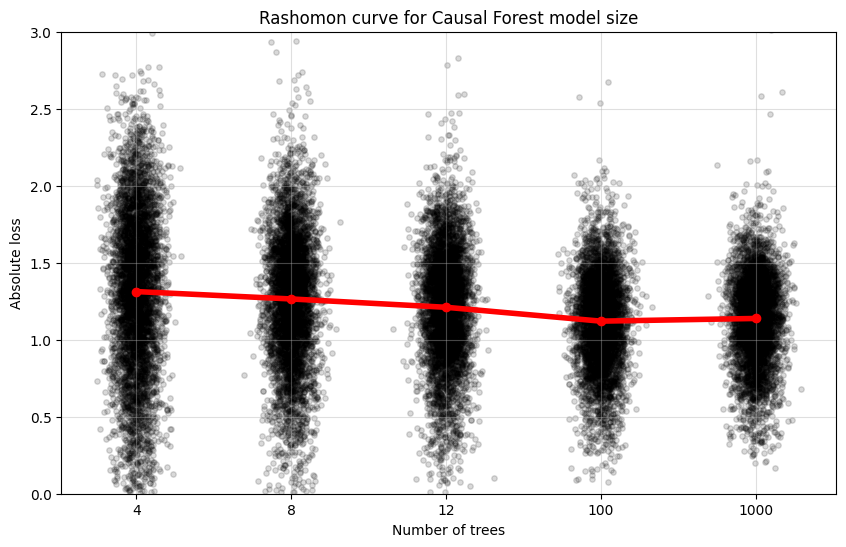

In [14]:
plt.figure(figsize=(10, 6))

# Puntos individuales
for n in rashomon_points["n_trees"].unique():
    subset = rashomon_points[rashomon_points["n_trees"] == n]

    x_jitter = np.random.normal(
        loc=list(rashomon_points["n_trees"].unique()).index(n),
        scale=0.08,
        size=len(subset)
    )

    plt.scatter(
        x_jitter,
        subset["absolute_loss"],
        alpha=0.15,
        s=15,
        color="black"
    )

# Línea roja con la media
x_positions = np.arange(len(rashomon_mean))

plt.plot(
    x_positions,
    rashomon_mean["mean_loss"],
    marker="o",
    linewidth=4,
    color="red"
)

plt.xticks(
    x_positions,
    rashomon_mean["n_trees"]
)

plt.xlabel("Number of trees")
plt.ylabel("Absolute loss")
plt.title("Rashomon curve for Causal Forest model size")

plt.ylim(0, 3)
plt.grid(True, alpha=0.4)

plt.show()

## 2. Best Linear Projection (BLP)

The Best Linear Projection (BLP) approximates the estimated Conditional Average Treatment Effects (CATEs) by projecting them onto a linear function of covariates:

$$
\tau(X) \approx X' \beta
$$

where $\beta$ is defined as the solution to:

$$
\beta = \arg\min_b \mathbb{E}\left[(\tau(X) - X'b)^2\right]
$$

This provides the best linear approximation to potentially complex and nonlinear treatment effect heterogeneity.

The BLP improves interpretability by summarizing heterogeneous effects through a small set of coefficients, allowing a direct assessment of how each covariate is associated with variation in treatment effects.

However, this gain in interpretability comes at the cost of flexibility, as it imposes a linear structure on heterogeneity and may fail to capture important nonlinear patterns present in the data.


In [15]:
## Best Linear Projection

df["estimated_effect"] = np.asarray(cate_hat).ravel()

X_blp = sm.add_constant(X_encoded, has_constant="add")

# Convertir a dataframe numérico
X_blp = pd.DataFrame(X_blp)
X_blp = X_blp.apply(pd.to_numeric, errors="coerce")

y_blp = pd.Series(df["estimated_effect"])
y_blp = pd.to_numeric(y_blp, errors="coerce")

# Unimos y eliminamos posibles NaN
blp_data = pd.concat(
    [y_blp.rename("estimated_effect"), X_blp],
    axis=1
).dropna()

y_blp_clean = blp_data["estimated_effect"].to_numpy(dtype=float)
X_blp_clean = blp_data.drop(columns="estimated_effect").to_numpy(dtype=float)

blp_model = sm.OLS(
    y_blp_clean,
    X_blp_clean
).fit()

print(blp_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     607.5
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        08:07:54   Log-Likelihood:                -699.85
No. Observations:                5000   AIC:                             1466.
Df Residuals:                    4967   BIC:                             1681.
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2066      0.023     97.915      0.0

In [16]:
coef_table = pd.DataFrame({
    "variable": ["const"] + list(X_encoded.columns),
    "coef": blp_model.params,
    "p_value": blp_model.pvalues
})

print(coef_table)

                    variable      coef        p_value
0                      const  2.206625   0.000000e+00
1                       size -0.001765   5.327753e-32
2                        age  0.001450   2.680904e-07
3               productivity  0.006595  4.789379e-126
4                 debt_ratio -1.001144  1.659788e-298
5              profitability  6.487836   0.000000e+00
6              sector_code_F -0.031774   3.454889e-02
7              sector_code_G  0.030450   1.258439e-02
8              sector_code_H -0.068091   1.290711e-04
9              sector_code_I -0.057799   3.560861e-04
10             sector_code_J  1.208634   0.000000e+00
11             sector_code_M  0.060225   9.028601e-05
12             sector_code_N  0.003395   8.536951e-01
13             sector_code_Q -0.026144   3.103578e-01
14             sector_code_R  0.018256   5.590324e-01
15             region_Aragon  0.000401   9.874406e-01
16           region_Asturias -0.012658   6.778026e-01
17   region_Balearic Islands

In [17]:

# BLP predictions

df["blp_prediction"] = blp_model.predict(X_blp)

rmse_blp = np.sqrt(
    mean_squared_error(
        df["estimated_effect"],
        df["blp_prediction"]
    )
)

print("BLP RMSE:", rmse_blp)


BLP RMSE: 0.2783242427390421


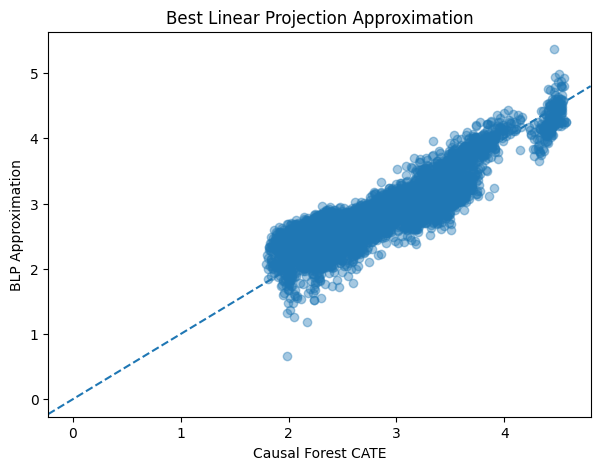

In [18]:

# Compare Causal Forest vs BLP

plt.figure(figsize=(7, 5))

plt.scatter(
    df["estimated_effect"],
    df["blp_prediction"],
    alpha=0.4
)

plt.xlabel("Causal Forest CATE")
plt.ylabel("BLP Approximation")

plt.title(
    "Best Linear Projection Approximation"
)

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.show()


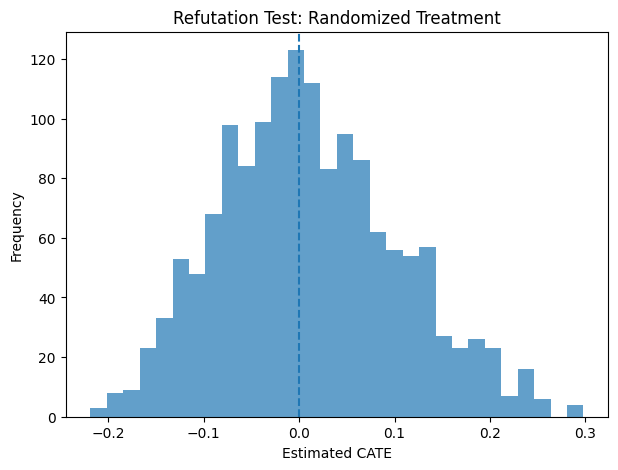

Media CATE (tratamiento aleatorio):
0.011198387543880087

Desviación estándar:
0.09345505406577401


In [19]:
# ==========================================================
# REFUTATION TEST 1:
# RANDOMIZE TREATMENT
# ==========================================================

# Idea:
# Rompemos artificialmente la relación causal
# aleatorizando la asignación del tratamiento.

# Si el modelo sigue encontrando efectos fuertes,
# probablemente existe overfitting o leakage.

from sklearn.model_selection import train_test_split

# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================

X_train, X_test, Y_train, Y_test, T_train, T_test = train_test_split(
    X_encoded,
    Y,
    T,
    test_size=0.30,
    random_state=42
)

# Tratamiento aleatorio
T_random = np.random.permutation(T)

# Nuevo Causal Forest
cf_random_treatment = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    n_estimators=1000,
    min_samples_leaf=50,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Ajustar modelo
cf_random_treatment.fit(
    Y_train,
    T_random[X_train.index],
    X=X_train
)

# Estimar efectos
cate_random_treatment = cf_random_treatment.effect(X_test)

# ==========================================================
# VISUALIZACIÓN
# ==========================================================

plt.figure(figsize=(7,5))

plt.hist(
    cate_random_treatment,
    bins=30,
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Refutation Test: Randomized Treatment"
)

plt.xlabel("Estimated CATE")
plt.ylabel("Frequency")

plt.show()

# ==========================================================
# RESULTADOS
# ==========================================================

print("Media CATE (tratamiento aleatorio):")
print(np.mean(cate_random_treatment))

print("\nDesviación estándar:")
print(np.std(cate_random_treatment))

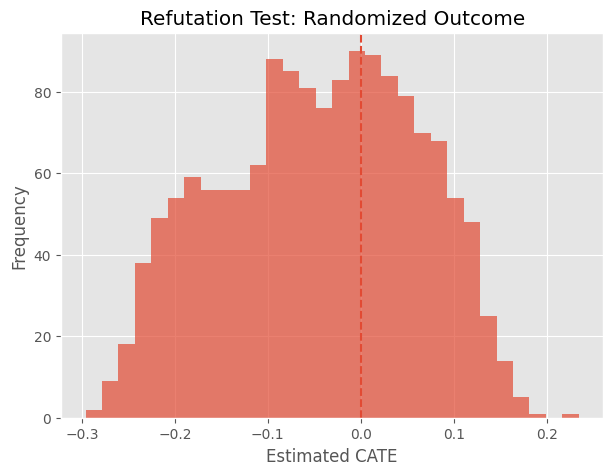

Media CATE (outcome aleatorio):
-0.045591824952160645

Desviación estándar:
0.10529594315731458


In [38]:
# ==========================================================
# REFUTATION TEST 2:
# RANDOMIZE OUTCOME
# ==========================================================

# Idea:
# Aleatorizamos el outcome y destruimos
# toda estructura causal real.


# Outcome aleatorio
Y_random = np.random.permutation(Y)

# Nuevo Causal Forest
cf_random_outcome = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    n_estimators=1000,
    min_samples_leaf=50,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Ajustar modelo
cf_random_outcome.fit(
    Y_random[X_train.index],
    T_train,
    X=X_train
)

# Estimar efectos
cate_random_outcome = cf_random_outcome.effect(X_test)

# ==========================================================
# VISUALIZACIÓN
# ==========================================================

plt.figure(figsize=(7,5))

plt.hist(
    cate_random_outcome,
    bins=30,
    alpha=0.7
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Refutation Test: Randomized Outcome"
)

plt.xlabel("Estimated CATE")
plt.ylabel("Frequency")

plt.show()

# ==========================================================
# RESULTADOS
# ==========================================================

print("Media CATE (outcome aleatorio):")
print(np.mean(cate_random_outcome))

print("\nDesviación estándar:")
print(np.std(cate_random_outcome))

In [39]:
# ==========================================================
# PROPENSITY SCORE MODEL
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

# Modelo propensity
ps_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

# Ajustar modelo
ps_model.fit(
    X_encoded,
    T
)

# Propensity scores estimados
propensity_scores = ps_model.predict_proba(X_encoded)[:, 1]

# Guardar en dataframe
df["propensity_score"] = propensity_scores

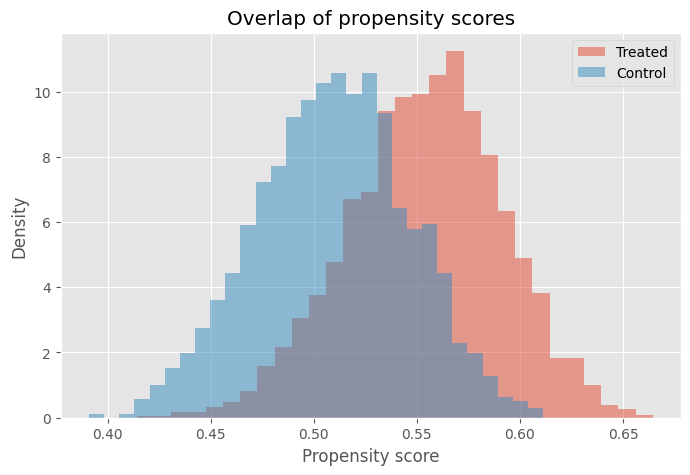

In [40]:
# ==========================================================
# PROPENSITY SCORE OVERLAP
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Tratados
plt.hist(
    df.loc[df["aid_received"] == 1, "propensity_score"],
    bins=30,
    alpha=0.5,
    density=True,
    label="Treated"
)

# Controles
plt.hist(
    df.loc[df["aid_received"] == 0, "propensity_score"],
    bins=30,
    alpha=0.5,
    density=True,
    label="Control"
)

plt.xlabel("Propensity score")
plt.ylabel("Density")

plt.title(
    "Overlap of propensity scores"
)

plt.legend()

plt.show()